In [1]:
import torchvision
import torch.nn as nn
import torch
import torch.nn.functional as F
from torchvision import transforms,models,datasets
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from torch import optim
device = 'cuda' if torch.cuda.is_available() else 'cpu'
import cv2, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from glob import glob

In [2]:
print(f"We are using {device} for training")

We are using cpu for training


In [ ]:
!cp /content/drive/MyDrive/theThirdAI/archive.zip /content/  # copia o dataset cats vs dogs do drive montado pro ambiente local do colab

cp: cannot stat '/content/drive/MyDrive/theThirdAI/archive.zip': No such file or directory


In [ ]:
!unzip archive.zip

In [5]:
train_data_dir = '/content/training_set/training_set'
test_data_dir = '/content/test_set/test_set'

In [ ]:
from torch.utils.data import Dataset, DataLoader
class cats_dogs(Dataset):
  def __init__(self, folder):
    cats = glob(folder+'/cats/*.jpg')
    dogs = glob(folder+'/dogs/*.jpg')
    self.fpaths = cats + dogs
    from random import shuffle, seed; seed(10); shuffle(self.fpaths)  # embaralha os caminhos dos arquivos
    self.targets = [fpath.split('/')[-1].startswith('dog') for fpath in self.fpaths]  # label direto pelo nome do arquivo
  def __len__(self): return len(self.fpaths)
  def __getitem__(self, ix):
    f = self.fpaths[ix]
    target = self.targets[ix]
    im = (cv2.imread(f)[:,:,::-1])  # [:,:,::-1] inverte a ordem dos canais e converte BGR pra RGB
    im = cv2.resize(im, (224, 224))  # 224x224 é o tamanho de entrada padrão pra varias arquiteturas prontas
    return torch.tensor(im/255).permute(2,0,1).to(device).float(), torch.tensor([target]).float().to(device)  # permute muda de (H,W,C) pra (C,H,W)

In [7]:
data = cats_dogs(train_data_dir)
im, label = data[200]

tensor([1.])


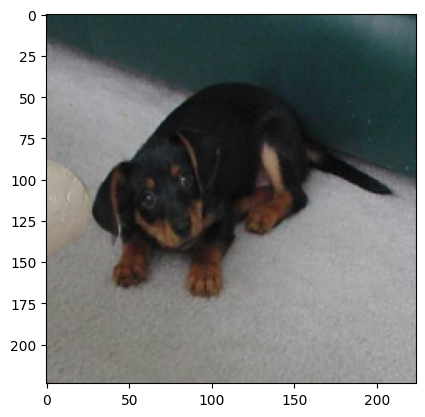

In [ ]:
plt.imshow(im.permute(1,2,0).cpu())  # permute de volta pra (H,W,C) so pra conseguir mostrar com o matplotlib
print(label)

In [ ]:
def conv_layer(ni,no,kernel_size,stride=1): # função auxiliar pra não repetir o mesmo bloco Conv+ReLU+BatchNorm+Pool várias vezes
  return nn.Sequential(
      nn.Conv2d(ni, no, kernel_size, stride),
      nn.ReLU(),
      nn.BatchNorm2d(no),# normaliza a saída da conv, ajuda a estabilizar/acelerar o treino
      nn.MaxPool2d(2)
  )
def get_model():
  model = nn.Sequential(
      conv_layer(3, 64, 3),# entrada com 3 canais (RGB)
      conv_layer(64, 512, 3),
      conv_layer(512, 512, 3),
      conv_layer(512, 512, 3),
      conv_layer(512, 512, 3),
      conv_layer(512, 512, 3),
      nn.Flatten(),
      nn.Linear(512, 1),
      nn.Sigmoid(),
  ).to(device)
  loss_fn = nn.BCELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
  return model, loss_fn, optimizer

In [ ]:
from torchsummary import summary # equivalente ao model.summary() do keras mas precisa informar o input_size
model, loss_fn, optimizer = get_model()
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 222, 222]           1,792
              ReLU-2         [-1, 64, 222, 222]               0
       BatchNorm2d-3         [-1, 64, 222, 222]             128
         MaxPool2d-4         [-1, 64, 111, 111]               0
            Conv2d-5        [-1, 512, 109, 109]         295,424
              ReLU-6        [-1, 512, 109, 109]               0
       BatchNorm2d-7        [-1, 512, 109, 109]           1,024
         MaxPool2d-8          [-1, 512, 54, 54]               0
            Conv2d-9          [-1, 512, 52, 52]       2,359,808
             ReLU-10          [-1, 512, 52, 52]               0
      BatchNorm2d-11          [-1, 512, 52, 52]           1,024
        MaxPool2d-12          [-1, 512, 26, 26]               0
           Conv2d-13          [-1, 512, 24, 24]       2,359,808
             ReLU-14          [-1, 512,

In [11]:
def train_batch(x, y, model, opt, loss_fn):
  prediction = model(x)
  batch_loss = loss_fn(prediction, y)
  batch_loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  return batch_loss.item()

@torch.no_grad()
def accuracy(x, y, model):
  prediction = model(x)
  is_correct = (prediction > 0.5) == y  # threshold de 0.5 pra transformar a probabilidade em classe 0/1
  return is_correct.cpu().numpy().tolist()

In [ ]:
def get_data():
  train = cats_dogs(train_data_dir)
  trn_dl = DataLoader(train, batch_size=32, shuffle=True, drop_last=True)  # drop_last descarta o ultimo batch se ele vier incompleto
  val = cats_dogs(test_data_dir)
  val_dl = DataLoader(val, batch_size=32, shuffle=True, drop_last=True)
  return trn_dl, val_dl

In [13]:
@torch.no_grad()
def val_loss(x, y, model):
  prediction = model(x)
  val_loss = loss_fn(prediction, y)
  return val_loss.item()

In [14]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

In [ ]:
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
for epoch in range(5):

  print(epoch)
  train_epoch_losses, train_epoch_accuracies = [], []
  val_epoch_accuracies = []
  for ix, batch in enumerate(iter(trn_dl)):
    #print(ix)
    x, y = batch
    batch_loss = train_batch(x, y, model, optimizer, loss_fn)
    train_epoch_losses.append(batch_loss)
  train_epoch_loss = np.array(train_epoch_losses).mean()

  for ix, batch in enumerate(iter(trn_dl)):
    x, y = batch
    is_correct = accuracy(x, y, model)
    train_epoch_accuracies.extend(is_correct)
  train_epoch_accuracy = np.mean(train_epoch_accuracies)

  for ix, batch in enumerate(iter(trn_dl)):
    x, y = batch
    val_is_correct = accuracy(x, y, model)
    val_epoch_accuracies.extend(val_is_correct)
    #validation_loss = val_loss(x, y, model)
  val_epoch_accuracy = np.mean(val_epoch_accuracies)

  train_losses.append(train_epoch_loss)
  train_accuracies.append(train_epoch_accuracy)
  #val_losses.append(validation_loss)
  val_accuracies.append(val_epoch_accuracy)

In [ ]:
epochs = np.arange(5)+1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation accuracy with 4K data points used for training")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
#plt.ylim(0.8,1)
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid('off')
plt.show()